In [12]:


import pandas as pd
import matplotlib.pyplot as plt


In [13]:



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,roc_curve


In [14]:


from google.colab import files
uploaded = files.upload()



Saving hospital_readmissions_30k.csv to hospital_readmissions_30k (3).csv


In [15]:
import pandas as pd

df = pd.read_csv("hospital_readmissions_30k.csv")


# Remove patient ID
df = df.drop("patient_id",axis=1);


# Separate features and targets
X = df.drop("readmitted_30_days",axis=1)
y = df["readmitted_30_days"]


# Convert categorical columns into numerical columns
X = pd.get_dummies(X,drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split

# split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


from sklearn.linear_model import LogisticRegression

# Logistic Regression with L2 regularization
model = LogisticRegression(
  penalty="l2",
  C=1.0,
  max_iter=5000 # Increased max_iter to ensure convergence
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Now we will train the model using the scaled data.

ROC-AUC: 0.5214502135137056


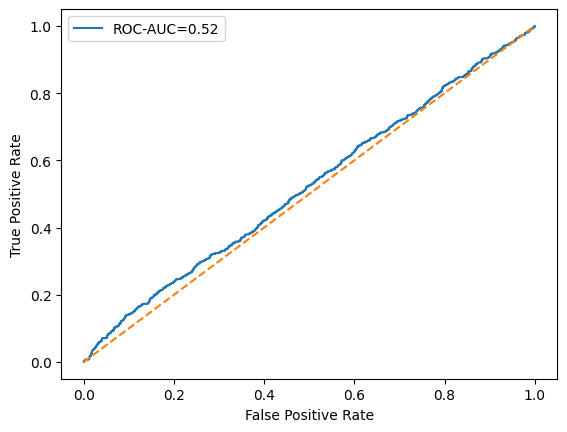

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Train the model using scaled data
model.fit(X_train_scaled, y_train)

# Predict Probablity of class 1 using scaled data
y_prob = model.predict_proba(X_test_scaled)[:,1]

# ROC-AUC score
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:",auc)

# auc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Yes')

plt.plot(fpr, tpr, label=f"ROC-AUC={auc:.2f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()